In [1]:
# Load the autoreload extension
%load_ext autoreload
# Set autoreload to reload all modules before executing code
%autoreload 2

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
from pathlib import Path 
from tqdm import tqdm
from copy import deepcopy
import pandas as pd 

from utils import *
from style import set_style
set_style()


print('Listing the number of imgs:')
imgs = list(Path('/Data_large/marine/Datasets/VENuS/ds_L0/perfect').glob('*.tif'))
print(len(imgs))

train_coco_path = '/Data_large/marine/Datasets/VENuS/annotations/perfect/train.json'
val_coco_path = '/Data_large/marine/Datasets/VENuS/annotations/perfect/val.json'
test_coco_path = '/Data_large/marine/Datasets/VENuS/annotations/perfect/test.json'

train_coco = get_coco(train_coco_path)
val_coco = get_coco(val_coco_path)
test_coco = get_coco(test_coco_path)

annotations_train = train_coco['annotations']
annotations_val = val_coco['annotations']
annotations_test = test_coco['annotations']
annotations = annotations_train + annotations_val + annotations_test

images_train = train_coco['images']
images_val = val_coco['images']
images_test = test_coco['images']
images = images_train + images_val + images_test

imgidToImage = {x['id']:x['file_name'] for x in images} # dict because this is unique assignment
NameToID = {x['id']:x['file_name'] for x in images}

imgidAndBBox = [(x['image_id'],x['bbox']) for x in annotations] # list because assignment can be multiple
imgidAndBBoxAndType = [(x['image_id'],x['bbox'],x['vessel_type']) for x in annotations] # list because assignment can be multiple
imgidToBBox = convert_to_dict(imgidAndBBox)
filename_bbox = {imgidToImage[x]:y for x,y in imgidToBBox.items()}

nameToPaths = {x.name:x.as_posix() for x in imgs}
PathsToName = {x.as_posix():x.name for x in imgs}

Listing the number of imgs:
282


In [48]:
VERBOSE = False
# Initialize the dictionary:
annotations_x_band = {i:[] for i in range(1,13,1)}

DATASET = deepcopy(test_coco) # copy the dataset

for idx, item in enumerate(tqdm(DATASET['annotations'], desc="Processing annotations")):
    # deepcopy the item
    
    annotation_id = item['id']
    image_id = item['image_id']
    bbox = item['bbox']
    area = item['area']
    
    ## 1. Read the image
    ### Get image name and path
    name = imgidToImage[image_id]
    stem = name.split('.')[0]
    path = nameToPaths[name]
    
    if VERBOSE:
        print(f'Processing {name}')
        print(f'bbox: {bbox}')
        print(f'area: {area}')
        print(f'path: {path}')
    
    img = read_tif(file_path=path, band_indices=[1,2,3,4,5,6,7,8,9,10,11,12]) # read all the bands from the image
    
    # 2. Crop Img using bbox info  3. Save crops in the folders
    OutsideDict = {x:[] for x in [1,2,3,4,5,6,7,8,9,10,11,12]}
    InsideDict  = {x:[] for x in [1,2,3,4,5,6,7,8,9,10,11,12]}
    
    for sel_band in [1,2,3,4,5,6,7,8,9,10,11,12]:
        x, y, width, height = bbox
        # crop:
        cropped_array = deepcopy(img[0][sel_band][y:y+height, x:x+width])
        
        # crop larger area for bg statistics:
        DxDy = 128//2
        cropped_array_bg = deepcopy(img[0][sel_band][y-DxDy:y+height+DxDy, x-DxDy:x+width+DxDy])
        # Calculate center coordinates
        center_x, center_y = width // 2, height // 2
        # Define the size of the center region to remove (e.g., 50% of width and height)
        center_width, center_height = width // 2, height // 2
        # Calculate the bounds of the center region
        center_x1, center_y1 = center_x - center_width // 2, center_y - center_height // 2
        center_x2, center_y2 = center_x + center_width // 2, center_y + center_height // 2
        
        center_x1 += DxDy
        center_x2 += DxDy
        center_y1 += DxDy
        center_y2 += DxDy
        
        
        # 4. Thresholding
        img_x_method = {}
        for method in ('otsu', 'li', 'isodata', 'mean'):
            try:
                img_x_method[method] = threshold(cropped_array, method=method)
            except Exception as e:
                img_x_method[method] = np.zeros_like(cropped_array, dtype=bool)
                print(f'Error in {method}.')
                print(e)

        # Combine masks where at least two agree
        combined_mask = np.zeros_like(cropped_array, dtype=bool)
        mask_count = sum(img_x_method.values())
        combined_mask[mask_count >= 2] = True
        # If no foreground pixels, skip to the next iteration
        if combined_mask.sum() == 0:
            continue

        # Calculate statistics over the combined mask
        flattened = cropped_array[combined_mask].flatten()
        if VERBOSE:
            print('Int shape:', cropped_array.shape)
        mean_value = np.mean(flattened)
        std_value = np.std(flattened)
        InsideDict[sel_band].append({'mean': mean_value, 'std': std_value})
        
        
        
        
        # Set the center region to NaN
        buffer = 60//2 # 60 pixels
        cropped_array_bg[center_y1-buffer:center_y2+buffer, center_x1-buffer:center_x2+buffer] = np.nan
        
        # Flatten the array
        flattened_bg = cropped_array_bg.flatten()
        # Remove all zero values
        flattened_bg = flattened_bg[flattened_bg != 0]
        if VERBOSE:
            print('Ext shape:', cropped_array_bg.shape)
            print('Ext flattened shape:', flattened_bg.shape)
        
        # Calculate mean and standard deviation, ignoring NaN values
        mean_value = np.nanmean(flattened_bg)
        std_value = np.nanstd(flattened_bg)
        
        OutsideDict[sel_band].append({'mean':mean_value, 'std':std_value})
        
    # if idx == 0:
    #     break

Processing annotations:   0%|          | 3/845 [00:00<02:30,  5.60it/s]/tmp/ipykernel_543279/114858076.py:97: RuntimeWarning: Mean of empty slice
  mean_value = np.nanmean(flattened_bg)
/home/vessel/anaconda3/envs/openmmlab/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
Processing annotations:   8%|▊         | 67/845 [00:12<02:42,  4.78it/s]/home/vessel/anaconda3/envs/openmmlab/lib/python3.8/site-packages/skimage/filters/thresholding.py:535: RuntimeWarning: invalid value encountered in divide
  lower = csum_intensity[:-1] / csuml[:-1]
/home/vessel/anaconda3/envs/openmmlab/lib/python3.8/site-packages/skimage/filters/thresholding.py:536: RuntimeWarning: invalid value encountered in divide
  higher = (csum_intensity[-1] - csum_intensity[:-1]) / csumh[:-1]
Processing annotations:   8%|▊         | 68/845 [00:12<02:42,  4.79it/s]

Error in isodata.
index 0 is out of bounds for axis 0 with size 0
Error in isodata.
index 0 is out of bounds for axis 0 with size 0
Error in isodata.
index 0 is out of bounds for axis 0 with size 0


Processing annotations:  16%|█▌        | 137/845 [00:26<01:58,  5.96it/s]/home/vessel/anaconda3/envs/openmmlab/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/vessel/anaconda3/envs/openmmlab/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
Processing annotations:  16%|█▋        | 139/845 [00:26<01:52,  6.28it/s]

Error in otsu.
index 0 is out of bounds for axis 0 with size 0
Error in isodata.
index 0 is out of bounds for axis 0 with size 0
Error in otsu.
index 0 is out of bounds for axis 0 with size 0
Error in isodata.
index 0 is out of bounds for axis 0 with size 0
Error in otsu.
index 0 is out of bounds for axis 0 with size 0
Error in isodata.
index 0 is out of bounds for axis 0 with size 0
Error in otsu.
index 0 is out of bounds for axis 0 with size 0
Error in isodata.
index 0 is out of bounds for axis 0 with size 0
Error in otsu.
index 0 is out of bounds for axis 0 with size 0
Error in isodata.
index 0 is out of bounds for axis 0 with size 0
Error in otsu.
index 0 is out of bounds for axis 0 with size 0
Error in isodata.
index 0 is out of bounds for axis 0 with size 0
Error in otsu.
index 0 is out of bounds for axis 0 with size 0
Error in isodata.
index 0 is out of bounds for axis 0 with size 0
Error in otsu.
index 0 is out of bounds for axis 0 with size 0
Error in isodata.
index 0 is out o

Processing annotations:  21%|██        | 175/845 [00:34<02:21,  4.73it/s]

...

Processing annotations:  67%|██████▋   | 562/845 [01:44<00:44,  6.33it/s]

Error in isodata.
index 0 is out of bounds for axis 0 with size 0
Error in isodata.
index 0 is out of bounds for axis 0 with size 0
Error in isodata.
index 0 is out of bounds for axis 0 with size 0


Processing annotations:  92%|█████████▏| 775/845 [02:17<00:12,  5.72it/s]

Error in isodata.
index 0 is out of bounds for axis 0 with size 0
Error in isodata.
index 0 is out of bounds for axis 0 with size 0


Processing annotations: 100%|██████████| 845/845 [02:29<00:00,  5.67it/s]


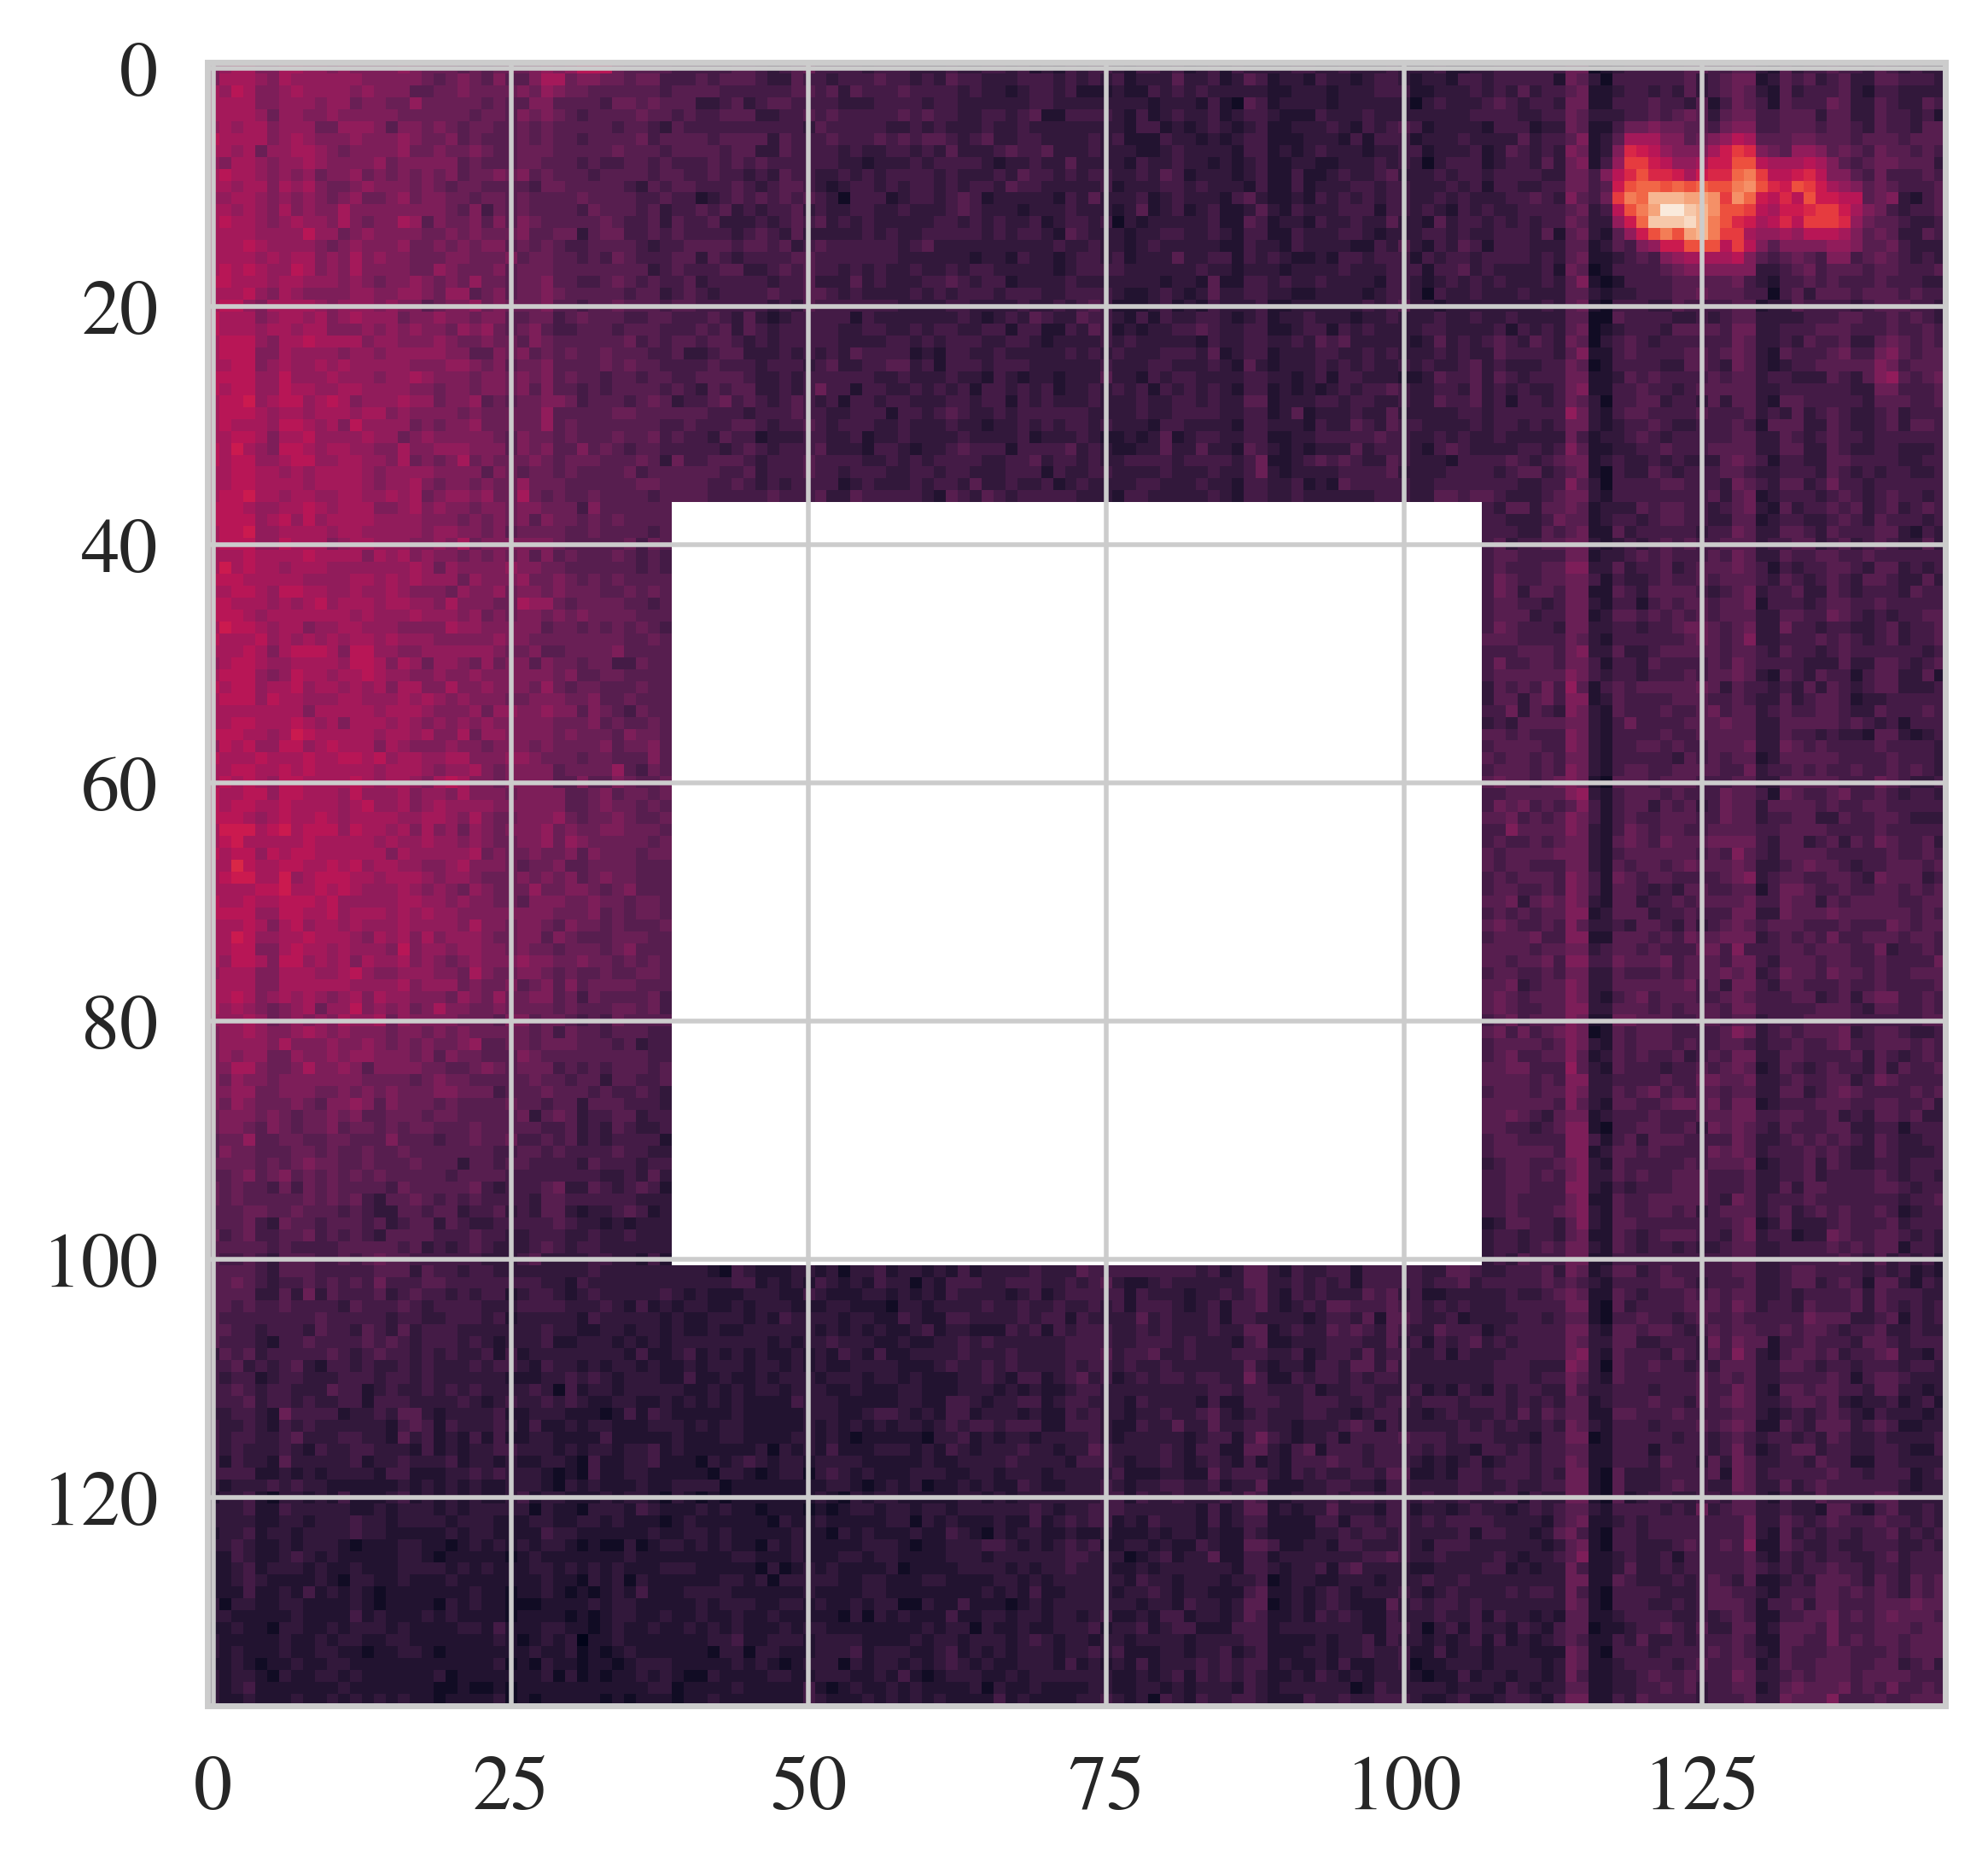

In [50]:
plt.imshow(cropped_array_bg)

In [49]:
insideResults = {x:[] for x in range(1,13,1)}
outsideResults = {x:[] for x in range(1,13,1)}

for Band in range(1,13,1):
    meanValues = [x['mean'] for x in InsideDict[Band]]
    stdValues = [x['std'] for x in InsideDict[Band]]
    insideResults[Band].append({'mean':np.mean(meanValues), 'std':np.mean(stdValues)})
    
    meanValues = [x['mean'] for x in OutsideDict[Band]]
    stdValues = [x['std'] for x in OutsideDict[Band]]
    outsideResults[Band].append({'mean':np.mean(meanValues), 'std':np.mean(stdValues)})

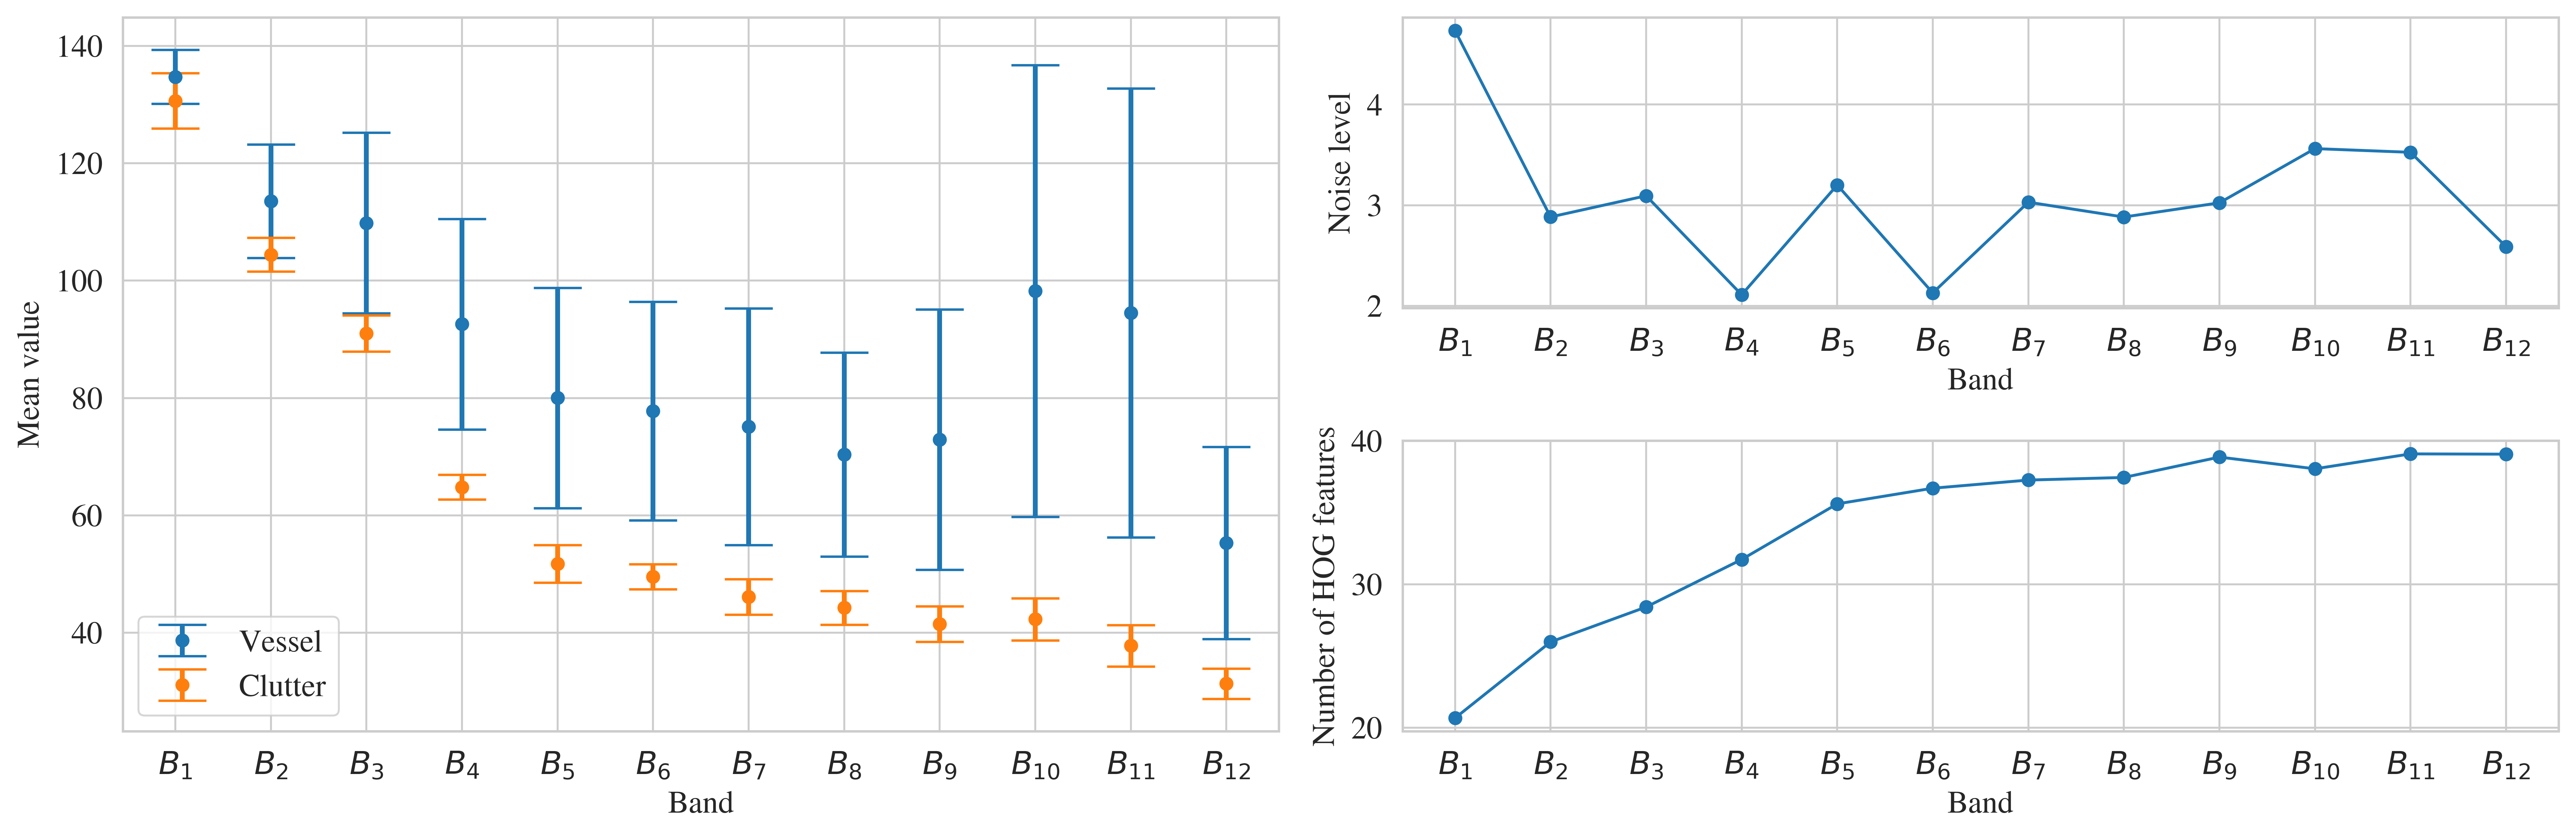

In [47]:
import matplotlib.pyplot as plt
from style import set_style

set_style(scale_factor=1.)
threshold_value = 0.7
band_num_hog = pd.read_pickle(f'hog/band_num_hog_{threshold_value}.pkl')


plt.subplot(1, 2, 1)

# Plot inside mean value with larger caps and lines
x = range(1, int(Band)+1)
xticks = [f'$B_{{{i}}}$' for i in x]  # Modify this line
y = [insideResults[x][0]['mean'] for x in range(1, int(Band)+1)]
yerr = [insideResults[x][0]['std'] for x in range(1, int(Band)+1)]
plt.errorbar(x, y, yerr=yerr, fmt='o', label='Vessel', capsize=10, elinewidth=2)

# Plot outside mean value with larger caps and lines
y = [outsideResults[x][0]['mean'] for x in range(1, int(Band)+1)]
yerr = [outsideResults[x][0]['std'] for x in range(1, int(Band)+1)]
plt.errorbar(x, y, yerr=yerr, fmt='o', label='Clutter', capsize=10, elinewidth=2)

plt.xlabel('Band')
plt.ylabel('Mean value')
plt.xticks(x, xticks)
plt.legend()

# Calculate the ratio of inside and outside std values
ratio = [insideResults[x][0]['mean'] / outsideResults[x][0]['mean'] for x in range(1, int(Band)+1)]
ratio_err = [np.sqrt((insideResults[x][0]['std']**2 + outsideResults[x][0]['std']**2) / (insideResults[x][0]['mean']**2 + outsideResults[x][0]['mean']**2)) for x in range(1, int(Band)+1)]  # Add this line

plt.subplot(2, 2, 2)
# Plot the ratio with larger caps and lines
# ax2.errorbar(x, np.array(ratio)/np.array(ratio_err), yerr=ratio_err, fmt='*', label='RatioErr', capsize=10, elinewidth=2)
plt.errorbar(x, yerr, yerr=None, fmt='-o', label='Ratio', capsize=10, elinewidth=2)  # Modify this line
plt.xlabel('Band')
plt.ylabel('Noise level')
plt.xticks(x,xticks)
# plt.legend()

plt.subplot(2, 2, 4)

# Plot the ratio with larger caps and lines
y = [np.mean(band_num_hog[x]) for x in range(1, int(Band)+1)]
plt.errorbar(x, y, yerr=None, fmt='-o', label='N. of HOG', capsize=10, elinewidth=2)  # Modify this line

plt.xlabel('Band')
plt.ylabel('Number of HOG features')
plt.xticks(x,xticks)
# plt.legend()


plt.tight_layout()
plt.show()


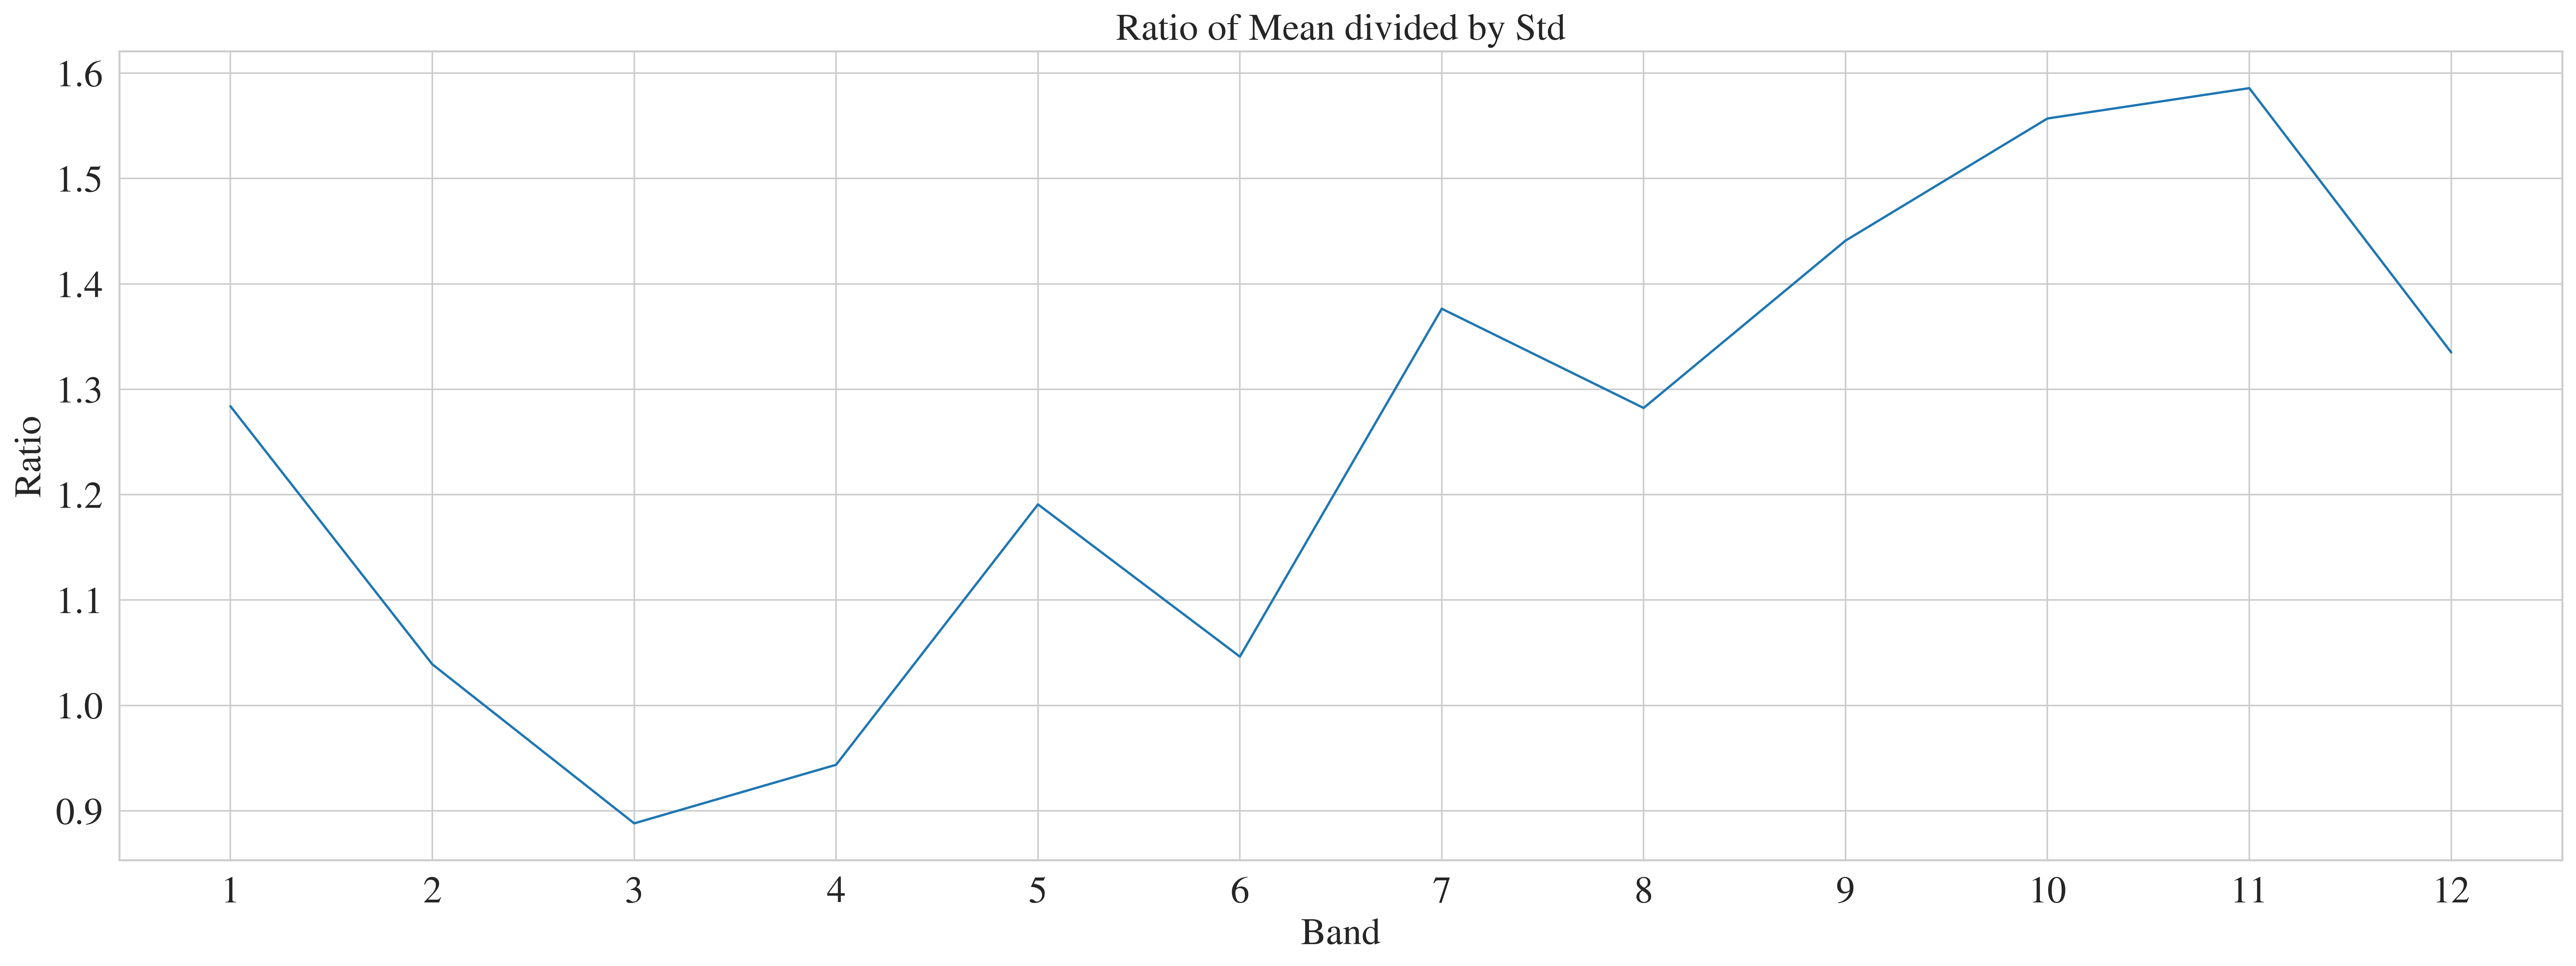

In [34]:
x = range(1, Band+1)
ratio_mean = [insideResults[i][0]['mean'] / outsideResults[i][0]['mean'] for i in x]
ratio_std = [insideResults[i][0]['std'] / outsideResults[i][0]['std'] for i in x]

plt.plot(x, np.array(ratio_mean) / np.array(ratio_std))
plt.xlabel('Band')
plt.ylabel('Ratio (Mean / Std)')
plt.title('Ratio of Mean divided by Std')

plt.xlabel('Band')
plt.ylabel('Ratio')
plt.xticks(x)
ax2.legend()
plt.show()

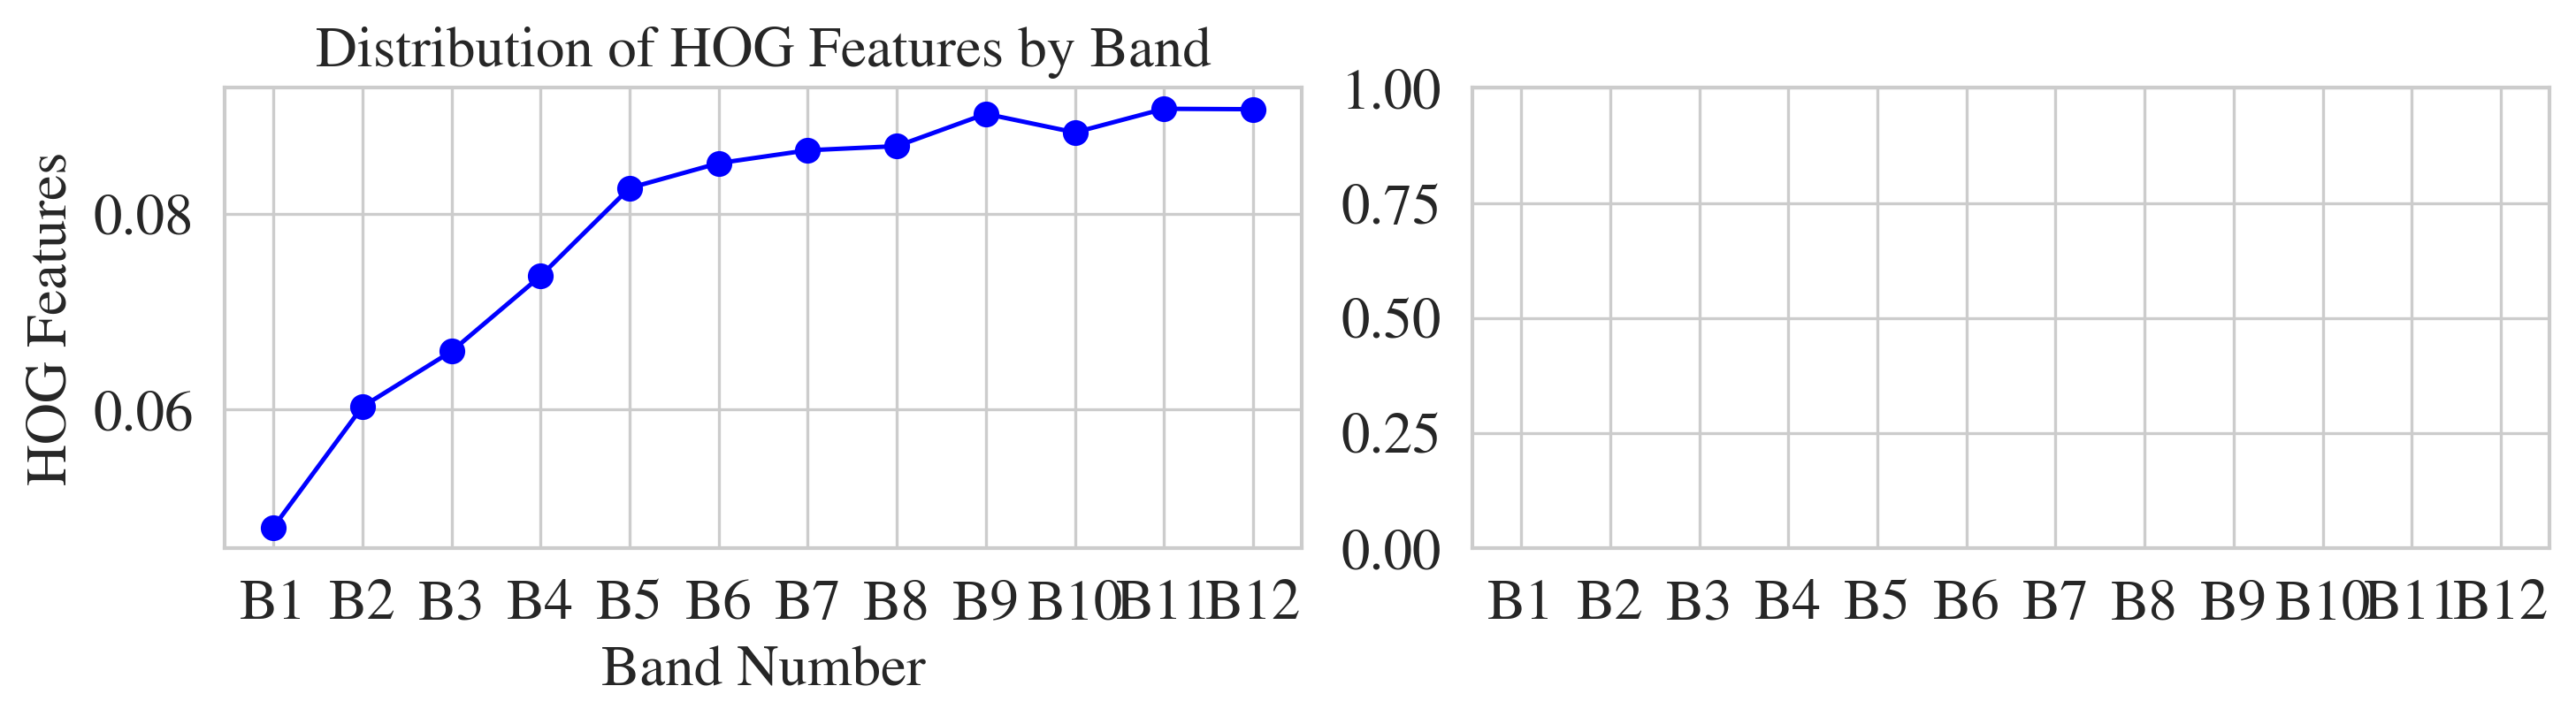

In [35]:
from pathlib import Path 
import os
import numpy as np
import pandas as pd 

from style import set_style

set_style(scale_factor=1.2)
threshold_value = 0.7
band_num_hog = pd.read_pickle(f'hog/band_num_hog_{threshold_value}.pkl')
# pd.to_pickle(stemToHog, f'stemToHog_{threshold_value}.pkl')

# Example usage
plot_hog_n_noise(band_num_hog)